In [1]:
import sys
from pathlib import Path
import warnings

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax
import jax.numpy as jnp
from jaxtyping import Array, Float, PRNGKeyArray, PyTree
from dataclasses import dataclass

from src.gaussian import GaussianProcess

import matplotlib.pyplot as plt

from tqdm import tqdm

import numpy as np
import pandas as pd

import equinox as eqx
import optax
import torch.utils.data as data

from laplax.curv.cov import create_posterior_fn
from laplax.curv.ggn import create_ggn_mv
from laplax.eval.pushforward import set_posterior_gp_kernel

from src.config import (DATA_PATHS, 
                        BIZ,
                        MC_LIGHT,
                        PLT_PARAMS)
from src.data import (load_data, 
                      split_card_data, 
                      split_transactions_by_cards, 
                      fit_transform_scale_features, 
                      transform_scale_features,
                      combine_business_consumer_sets,
                      make_xy)
from src.features import (date_span_days, 
                          build_all_mcc_similarity_features,
                          make_card_features_final)

from matplotlib.colors import LinearSegmentedColormap as _LSC
plt.rcParams.update(PLT_PARAMS)
_CM_CMAP = _LSC.from_list('mc_cm', [MC_LIGHT, BIZ])

# Data Loading & Pre-Processing

In [3]:
business, consumer, merchants = load_data(DATA_PATHS)

In [4]:
total_days = date_span_days(pd.concat([business, consumer]))

## Feature Construction

In [5]:
bus_features = make_card_features_final(business, 1, total_days)
consumer_features = make_card_features_final(consumer, 0, total_days)

In [6]:
card_splits = split_card_data(bus_features, consumer_features)

In [7]:
trans_splits = split_transactions_by_cards(business, consumer, card_splits)

(business_mcc_features_train, 
 consumer_mcc_features_train, 
 business_profile, 
 consumer_profile) = build_all_mcc_similarity_features(trans_splits["business"]["train"],
                                                               trans_splits["consumer"]["train"])

(business_mcc_features_val, 
 consumer_mcc_features_val,
 _, _) = build_all_mcc_similarity_features(trans_splits["business"]["val"],
                                                   trans_splits["consumer"]["val"],
                                                   business_profile,
                                                   consumer_profile)

(business_mcc_features_test, 
 consumer_mcc_features_test,
 _, _) = build_all_mcc_similarity_features(trans_splits["business"]["test"],
                                                   trans_splits["consumer"]["test"],
                                                   business_profile,
                                                   consumer_profile)

In [8]:
business_mcc_features = pd.concat([
    business_mcc_features_train, 
    business_mcc_features_val, 
    business_mcc_features_test
])

consumer_mcc_features = pd.concat([
    consumer_mcc_features_train, 
    consumer_mcc_features_val, 
    consumer_mcc_features_test
])

In [9]:
bus_features = bus_features.merge(
    business_mcc_features,
    on = "card_number", 
    how = "left"
)

consumer_features = consumer_features.merge(
    consumer_mcc_features,
    on = "card_number", 
    how = "left"
)

In [10]:
df_splits = split_card_data(bus_features, consumer_features, card_splits = card_splits)

In [11]:
combined_splits = combine_business_consumer_sets(df_splits["business"], df_splits["consumer"])

In [12]:
X, y = make_xy(combined_splits, target_col = "type")

In [13]:
for i in X:
    X[i].drop("card_number", axis = 1, inplace = True)

X["train"]

,online_share,recurring_ratio,repeated_amount_ratio,recurring_it_services_turnover_ratio,recurring_digital_turnover_ratio,share_merchant_country_Kazakhstan,share_merchant_country_US,share_merchant_country_Ireland,active_days_ratio,log_turnover_per_active_day,log_tx_per_active_day,mcc_business_similarity_gap,mcc_avg_distance
0,0.865169,0.067416,0.056180,0.158686,0.269754,0.505091,0.266643,0.000000,0.576923,11.428673,0.991487,0.021479,0.572035
1,0.891892,0.040541,0.033784,0.160647,0.160647,0.715180,0.275281,0.000000,0.494505,11.888500,0.972461,0.096675,0.654736
2,0.925000,0.150000,0.125000,0.290570,0.426691,0.512817,0.316392,0.144744,0.439560,12.233194,0.916291,0.172482,0.438594
3,0.870130,0.038961,0.032468,0.118540,0.118540,0.768027,0.137362,0.000000,0.510989,12.227733,0.976789,0.029696,0.383201
4,0.781818,0.163636,0.136364,0.169093,0.227021,0.610902,0.180040,0.000000,0.417582,12.144697,0.895013,0.099216,0.349801
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62995,0.542986,0.054299,0.045249,0.003050,0.025715,0.401011,0.059943,0.539046,0.681319,12.131302,1.023263,0.231059,0.493682
62996,0.607477,0.000000,0.000000,0.000000,0.000000,0.516619,0.041039,0.000000,0.412088,11.675676,0.886519,-0.174019,0.459430
62997,0.525424,0.101695,0.084746,0.000000,0.009808,0.743788,0.021895,0.000000,0.269231,11.138515,0.790311,-0.056356,0.342970
62998,0.455446,0.059406,0.049505,0.000000,0.099268,0.163838,0.002235,0.150890,0.357143,11.030232,0.937601,-0.201376,0.313016


In [14]:
X_train = X["train"]
X_val = X["val"]
X_test = X["test"]

y_train = y["train"]
y_val = y["val"]
y_test = y["test"]

## Scaling

In [15]:
features_to_scale = [
    "log_tx_per_active_day",
    "log_turnover_per_active_day"
]

In [16]:
X_train, scaler = fit_transform_scale_features(X_train, features_to_scale)
X_val = transform_scale_features(X_val, features_to_scale, scaler)
X_test = transform_scale_features(X_test, features_to_scale, scaler)

# Neural Network

In [17]:
# Make sure everything is JAX-friendly

X_train = jnp.asarray(X_train, dtype=jnp.float32)
X_val = jnp.asarray(X_val, dtype=jnp.float32)
X_test = jnp.asarray(X_test, dtype=jnp.float32)

y_train = jnp.asarray(y_train, dtype=jnp.float32).reshape(-1)
y_val = jnp.asarray(y_val, dtype=jnp.float32).reshape(-1)
y_test = jnp.asarray(y_test, dtype=jnp.float32).reshape(-1)

In [18]:
D = X_train.shape[1]

LAYER_SIZES = [D, 64, 64, 1]

PARAM_SCALE = 0.1

NUM_EPOCHS = 50
LEARNING_RATE = 0.001
BATCH_SIZE = 64
LOG_FREQUENCY = 100
KEY = jax.random.key(47)

In [19]:
class MLP(eqx.Module):
    layers: list[eqx.nn.Linear]

    def __init__(self, key: PRNGKeyArray, layer_sizes: list[int]) -> None:
        keys = jax.random.split(key, len(layer_sizes) - 1)
        self.layers = [
            eqx.nn.Linear(layer_sizes[i], layer_sizes[i+1], key=keys[i])
            for i in range(len(layer_sizes) - 1)
        ]

    def __call__(self, X: Float[Array, "D"]) -> Float[Array, "1"]:
        for i in range(len(self.layers) - 1):
            X = self.layers[i](X)
            X = jax.nn.relu(X)

        X = self.layers[-1](X)

        return X

In [20]:
KEY, model_key = jax.random.split(KEY, 2)

model = MLP(model_key, LAYER_SIZES)

In [21]:
# A helper collate function to create a datasets object.
# Taken from https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/guide4/Research_Projects_with_JAX.html

def numpy_collate(batch):
    if isinstance(batch[0], np.ndarray):
        return np.stack(batch)
    elif isinstance(batch[0], (tuple, list)):
        transposed = zip(*batch)
        return [numpy_collate(samples) for samples in transposed]
    else:
        return np.array(batch)


class MyDataset(data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.N = len(X)
        self.D = len(X[0])

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        return self.X[idx, :], self.y[idx]

In [22]:
train_dataset = MyDataset(X_train, y_train)
train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=numpy_collate,
    shuffle=True
)

val_dataset = MyDataset(X_val, y_val)
val_loader = data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=numpy_collate,
    shuffle=False
)

test_dataset = MyDataset(X_test, y_test)
test_loader = data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=numpy_collate,
    shuffle=False
)

In [23]:
@eqx.filter_jit
def loss_fn(model: MLP, X: Float[Array, "B D"], y: Float[Array, "B"]):
    pred_logits = jax.vmap(model)(X)[:, 0]

    return optax.losses.sigmoid_binary_cross_entropy(pred_logits, y).mean()


@eqx.filter_jit
def compute_accuracy(
    model: MLP,
    X: Float[Array, "B D"],
    y: Float[Array, "B"]
) -> Float[Array, ""]:
    pred_logits = jax.vmap(model)(X)[:, 0]
    pred = jnp.asarray(pred_logits > 0, dtype=jnp.float32)

    return jnp.mean(jnp.asarray(y == pred, dtype=jnp.int8))


def test(model: MLP, test_loader: data.DataLoader) -> tuple[Float[Array, ""], Float[Array, ""]]:
    loss = jnp.zeros(())
    acc = jnp.zeros(())

    for batch_X, batch_y in test_loader:
        loss += loss_fn(model, batch_X, batch_y)
        acc += compute_accuracy(model, batch_X, batch_y)

    return loss / len(test_loader), acc / len(test_loader)

In [24]:
optimizer = optax.adam(learning_rate=LEARNING_RATE)

In [25]:
def train(
    model: MLP,
    train_loader: data.DataLoader,
    val_loader: data.DataLoader,
    num_epochs: int,
    log_frequency: int
) -> MLP:
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    def make_step(
        model: MLP,
        opt_state: PyTree,
        batch_X: Float[Array, "B D"],
        batch_y: Float[Array, "B"]
    ) -> tuple[MLP, PyTree, Float[Array, ""]]:
        loss_value, grads = eqx.filter_value_and_grad(loss_fn)(model, batch_X, batch_y)

        updates, opt_state = optimizer.update(
            grads,
            opt_state,
            eqx.filter(model, eqx.is_array)
        )

        model = eqx.apply_updates(model, updates)

        return model, opt_state, loss_value

    losses = []
    pbar = tqdm(range(num_epochs), desc="Training")

    for epoch in pbar:
        for batch_X, batch_y in train_loader:
            model, opt_state, loss_value = make_step(
                model,
                opt_state,
                batch_X,
                batch_y
            )

            losses.append(loss_value)

        val_loss, val_acc = test(model, val_loader)

        if epoch % log_frequency == 0:
            pbar.set_postfix(
                epoch=epoch,
                train_loss=loss_value.item(),
                val_loss=val_loss.item(),
                val_accuracy=val_acc.item(),
            )

    return model, losses

In [26]:
model_trained, losses = train(
    model,
    train_loader,
    val_loader,
    num_epochs=NUM_EPOCHS,
    log_frequency=LOG_FREQUENCY
)

Training: 100%|██████████| 50/50 [12:51<00:00, 15.44s/it, epoch=0, train_loss=0.0124, val_accuracy=0.938, val_loss=0.147]


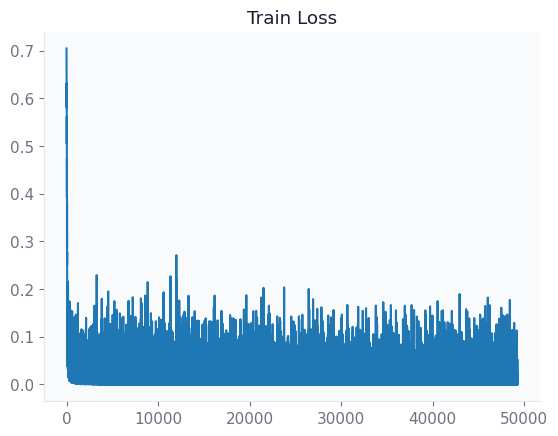

In [27]:
plt.plot(losses)
plt.title("Train Loss")
plt.show()

# Laplace Approximation

In [28]:
params_final, static = eqx.partition(model_trained, eqx.is_array)

def model_fn(params, input):
    new_model = eqx.combine(static, params)
    return new_model(input)

In [29]:
batch = {
    "input": X_train,
    "target": y_train
}

ggn_mv = create_ggn_mv(
    model_fn,
    params_final,
    batch,
    "binary_cross_entropy"
)

posterior_fn = create_posterior_fn(
    "full",
    ggn_mv,
    layout=params_final
)

In [30]:
prior_arguments = {
    "prior_prec": 1.0
}

laplax_gp_kernel, _ = set_posterior_gp_kernel(
    model_fn=model_fn,
    mean=params_final,
    posterior_fn=posterior_fn,
    prior_arguments=prior_arguments,
    dense=True,
    output_layout=1
)

In [31]:
@eqx.filter_jit
def mean_func(X: Float[Array, "B D"]) -> Float[Array, "B"]:
    return jax.vmap(model_trained)(X)[:, 0]


def vectorized_laplace_kernel(
    a: Float[Array, "B D"],
    b: Float[Array, "B D"]
):
    return jnp.vectorize(
        laplax_gp_kernel,
        signature="(d),(d)->(c,c)"
    )(a, b)[..., 0, 0]


laplace_posterior = GaussianProcess(
    mean_func,
    vectorized_laplace_kernel
)

In [32]:
def laplace_predict_proba(X):
    mX_laplax = laplace_posterior.mu(X)
    vX_laplax = laplace_posterior.k(X, X)

    prediction_laplax = jax.nn.sigmoid(
        mX_laplax / jnp.sqrt(1 + jnp.pi * vX_laplax / 8)
    )

    return prediction_laplax, mX_laplax, vX_laplax

In [33]:
p_train_laplace, m_train_laplace, v_train_laplace = laplace_predict_proba(X_train)
p_val_laplace, m_val_laplace, v_val_laplace = laplace_predict_proba(X_val)
p_test_laplace, m_test_laplace, v_test_laplace = laplace_predict_proba(X_test)

In [34]:
y_train_pred_laplace = jnp.asarray(p_train_laplace >= 0.5, dtype=jnp.float32)
y_val_pred_laplace = jnp.asarray(p_val_laplace >= 0.5, dtype=jnp.float32)
y_test_pred_laplace = jnp.asarray(p_test_laplace >= 0.5, dtype=jnp.float32)

train_acc_laplace = jnp.mean(y_train_pred_laplace == y_train)
val_acc_laplace = jnp.mean(y_val_pred_laplace == y_val)
test_acc_laplace = jnp.mean(y_test_pred_laplace == y_test)

print("Laplace train accuracy:", train_acc_laplace.item())
print("Laplace val accuracy:", val_acc_laplace.item())
print("Laplace test accuracy:", test_acc_laplace.item())

Laplace train accuracy: 0.9968095421791077
Laplace val accuracy: 0.9874761700630188
Laplace test accuracy: 0.9874761700630188


In [35]:
y_train = (y_train == 1).astype(jnp.float32)
y_val = (y_val == 1).astype(jnp.float32)
y_test = (y_test == 1).astype(jnp.float32)

In [36]:
from sklearn.metrics import confusion_matrix

threshold = 0

for thr in np.arange(0, 1.01, 0.01):
    y_val_pred = (p_val_laplace >= thr).astype(jnp.float32)
    
    cm = confusion_matrix(y_val, y_val_pred, normalize="true")
    if cm[1, 1] < 0.9995:
        threshold = thr - 0.01
        break

print(f"Chosen threshold: {threshold:.2f}")

Chosen threshold: 0.18


Text(0.5, 1.0, 'Confusion Matrix Validation at Threshold 0.18')

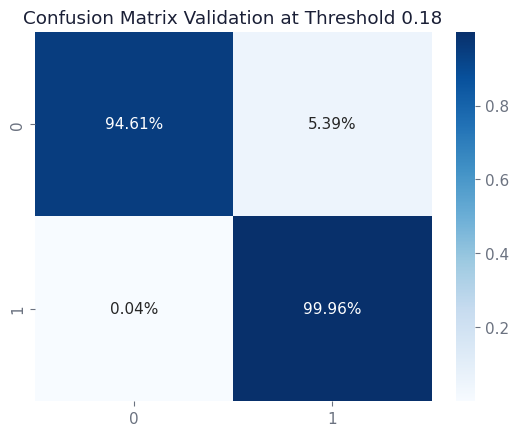

In [37]:
import seaborn as sns

cm = confusion_matrix(y_val, (p_val_laplace >= threshold).astype(jnp.float32), normalize="true")

sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues")
plt.title(f"Confusion Matrix Validation at Threshold {threshold:.2f}")

Text(0.5, 1.0, 'Confusion Matrix Test at Threshold 0.18')

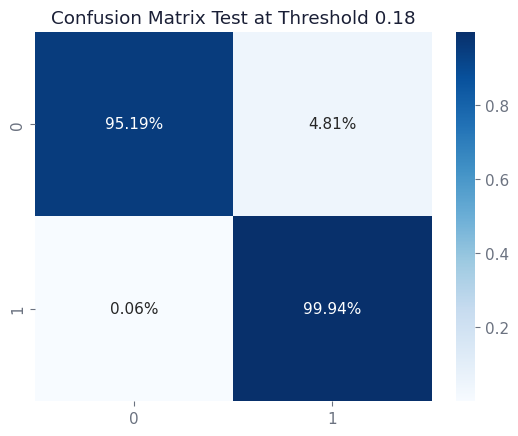

In [38]:
import seaborn as sns

cm = confusion_matrix(y_test, (p_test_laplace >= threshold).astype(jnp.float32), normalize="true")

sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues")
plt.title(f"Confusion Matrix Test at Threshold {threshold:.2f}")

In [39]:
predicted_frauds = pd.DataFrame({
    "prob_of_fraud": p_test_laplace[(y_test == 0) & (p_test_laplace >= threshold)],
    "variance": v_test_laplace[(y_test == 0) & (p_test_laplace >= threshold)]
})

predicted_frauds.sort_values(by = ["prob_of_fraud", "variance"], ascending = [False, True])

,prob_of_fraud,variance
253,0.976586,67.249398
41,0.975028,81.943374
332,0.971974,78.504826
241,0.970105,73.941688
170,0.965919,67.596093
...,...,...
643,0.180952,135.295676
319,0.180742,367.548238
232,0.180612,546.075783
317,0.180207,433.794346
